In [152]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [153]:
df = pd.read_csv('netflix_titles.csv')
print(df.head())

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

In [154]:
df.shape

(8807, 12)

In [155]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [156]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [157]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [158]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

In [159]:
df["type"].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [160]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [161]:
(df.isnull().sum() / len(df)) * 100 

show_id          0.000000
type             0.000000
title            0.000000
director        29.908028
cast             9.367549
country          9.435676
date_added       0.113546
release_year     0.000000
rating           0.045418
duration         0.034064
listed_in        0.000000
description      0.000000
dtype: float64

In [162]:
df.duplicated().sum()

np.int64(0)

In [163]:
df=df.dropna(subset=['date_added'])

In [164]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2624
cast             825
country          830
date_added         0
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [165]:
df=df.dropna(subset=["rating","duration"])

In [166]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2621
cast             825
country          829
date_added         0
release_year       0
rating             0
duration           0
listed_in          0
description        0
dtype: int64

In [167]:
df["director"]=df["director"].fillna("unknown")
df["cast"]=df["cast"].fillna("unknown")
df["country"]=df["country"].fillna("unknown")

In [168]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

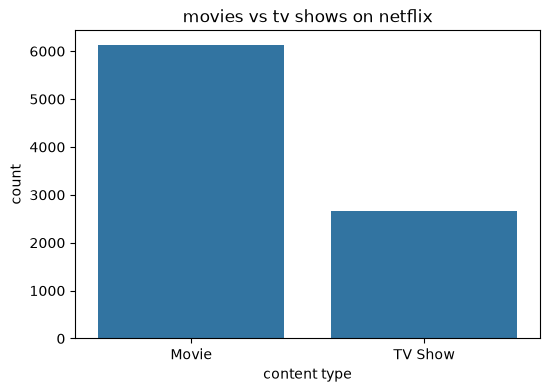

In [169]:
plt.figure(figsize=(6,4))
sns.countplot(x="type",data=df)

plt.title("movies vs tv shows on netflix")
plt.xlabel("content type")
plt.ylabel("count")

plt.show()


In [170]:
df["type"].value_counts()

type
Movie      6126
TV Show    2664
Name: count, dtype: int64

In [171]:
top_country=df["country"].value_counts().head(10)
print(top_country)

country
United States     2809
India              972
unknown            829
United Kingdom     418
Japan              243
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64


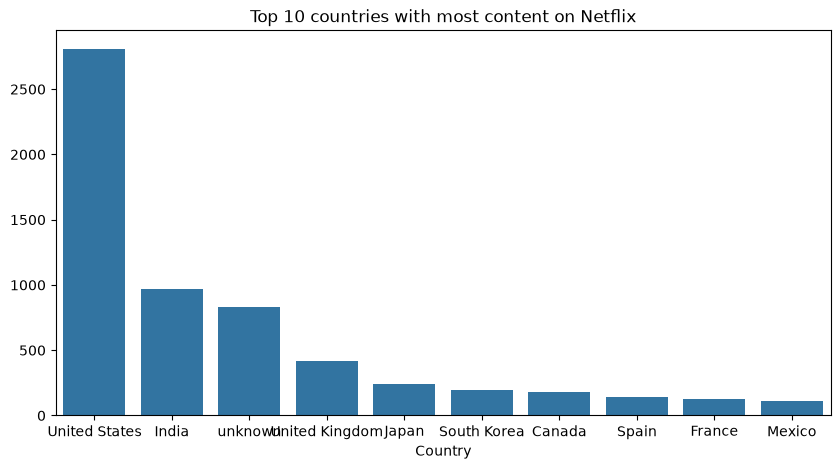

In [172]:
plt.figure(figsize=(10,5))
sns.barplot(x=top_country.index,y=top_country.values)
plt.title("Top 10 countries with most content on Netflix")
plt.xlabel("Number of titles")
plt.xlabel("Country")

plt.show()


In [173]:
release_year = df["release_year"].value_counts().sort_index()
print(release_year)

release_year
1925       1
1942       2
1943       3
1944       3
1945       4
        ... 
2017    1030
2018    1146
2019    1030
2020     953
2021     592
Name: count, Length: 74, dtype: int64


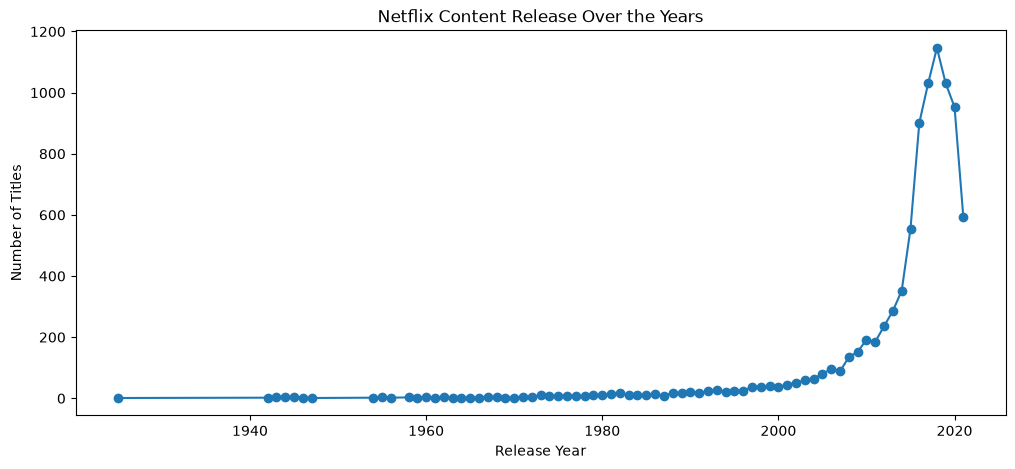

In [174]:
plt.figure(figsize=(12,5))

plt.plot(release_year.index,
         release_year.values,
         marker="o")

plt.title("Netflix Content Release Over the Years")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.show()

In [175]:
top_genres = df["listed_in"].value_counts().head(10)
print(top_genres)

listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
Kids' TV                                            219
Children & Family Movies                            215
Children & Family Movies, Comedies                  201
Documentaries, International Movies                 186
Dramas, International Movies, Romantic Movies       180
Name: count, dtype: int64


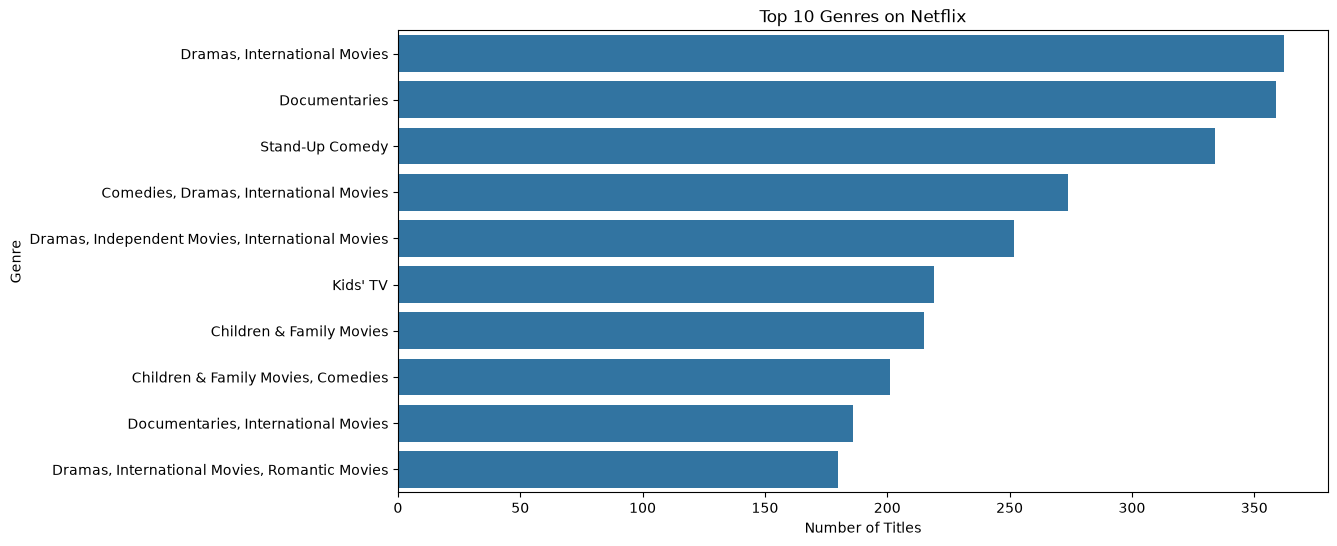

In [176]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_genres.values,
    y=top_genres.index
)

plt.title("Top 10 Genres on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")

plt.show()

In [177]:
top_ratings = df["rating"].value_counts().head(10)

print(top_ratings)

rating
TV-MA    3205
TV-14    2157
TV-PG     861
R         799
PG-13     490
TV-Y7     333
TV-Y      306
PG        287
TV-G      220
NR         79
Name: count, dtype: int64


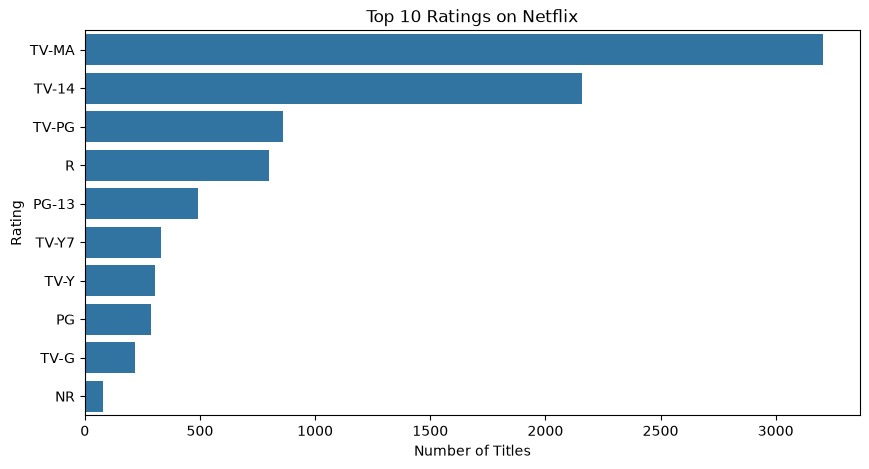

In [178]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=top_ratings.values,
    y=top_ratings.index
)

plt.title("Top 10 Ratings on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Rating")

plt.show()

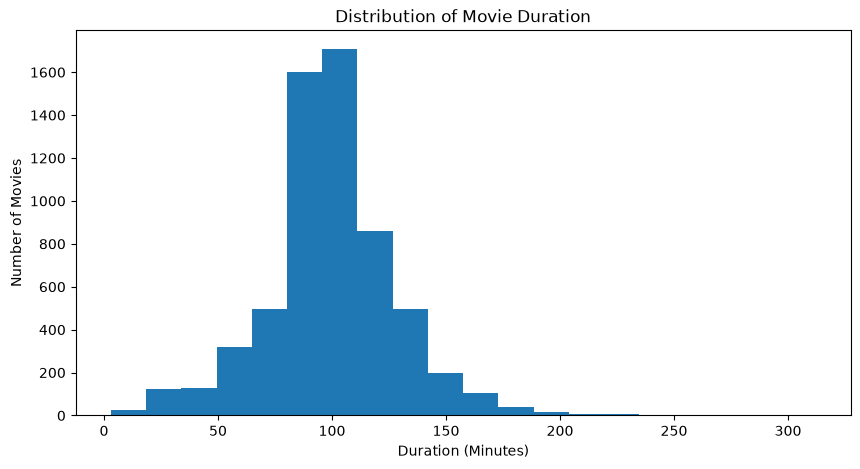

In [179]:
movies = df[df["type"] == "Movie"].copy()

movies["duration"] = movies["duration"].str.replace(" min", "").astype(int)

plt.figure(figsize=(10,5))

plt.hist(movies["duration"], bins=20)

plt.title("Distribution of Movie Duration")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Number of Movies")

plt.show()

In [180]:
tv = df[df["type"] == "TV Show"].copy()

tv["duration"] = tv["duration"].str.replace(" Seasons", "", regex=False)
tv["duration"] = tv["duration"].str.replace(" Season", "", regex=False)

tv["duration"] = tv["duration"].astype(int)

top_seasons = tv["duration"].value_counts().sort_index()

print(top_seasons)

duration
1     1791
2      421
3      198
4       94
5       64
6       33
7       23
8       17
9        9
10       6
11       1
12       2
13       2
15       2
17       1
Name: count, dtype: int64


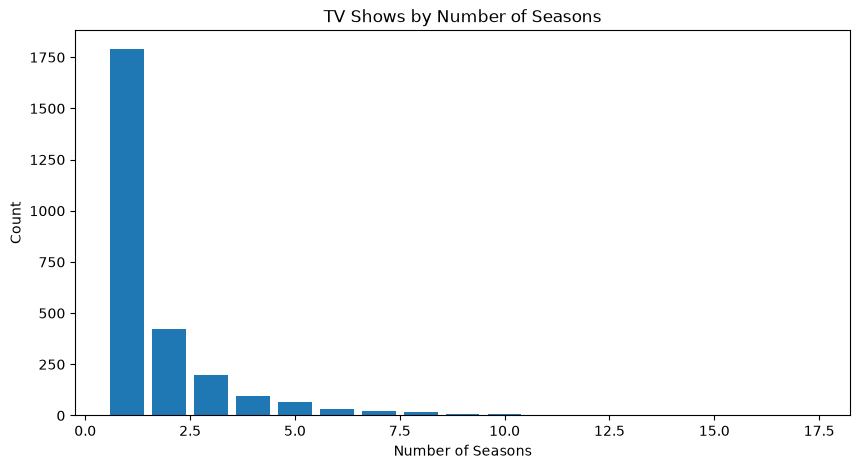

In [181]:
plt.figure(figsize=(10,5))

plt.bar(top_seasons.index, top_seasons.values)

plt.title("TV Shows by Number of Seasons")
plt.xlabel("Number of Seasons")
plt.ylabel("Count")

plt.show()

In [182]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

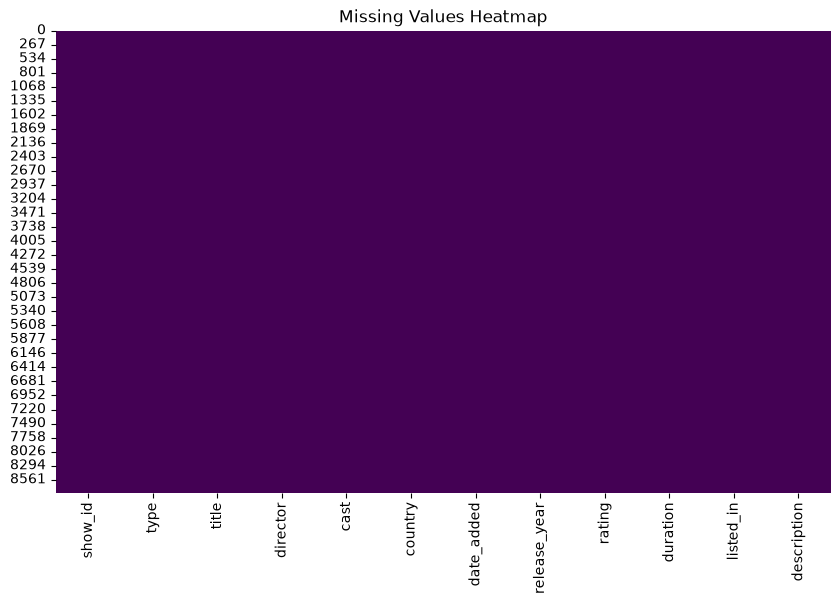

In [183]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

Key Insights

1. Netflix has more Movies (6,126) than TV Shows (2,664).


2. The United States has the most Netflix content, and India is in second place.


3. The number of Netflix releases increased quickly after 2015.


4. Drama and International Movies are the most common genres on Netflix.


5. TV-MA and TV-14 are the most common content ratings.


6. Most movies are between 80 and 110 minutes long.


7. Most TV Shows have only one season.